# Workshop: Autodifferentiation and Gradient Descent in TensorFlow

### Wednesday, April 26

Today's exercises will illustrate one of the most powerful tools available in TensorFlow: autodifferentiation.

The exercises and discussion below are largely based on the following two TF tutorials:

- https://www.tensorflow.org/guide/autodiff
- https://www.tensorflow.org/guide/advanced_autodiff

<b>Reminder:</b> if you have not already installed TensorFlow on your local machine, do so with `pip install tensorflow`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
print(tf.__version__)


## Review: why do we need gradients, anyway?

Almost any model we train in statistics and machine learning involves minimizing a loss with respect to a parameter $\theta$, usually something like
$$
L( \theta ) = \sum_{i=1}^n \ell( X_i, Y_i; \theta ),
$$
where $\ell( X_i, Y_i; \theta )$ is the loss (i.e., a cost we pay) on the $i$-th data point.

For example, in ordinary least squares simple linear regression, we find $a,b\in \mathbb{R}$ to minimize
$$
L( a,b ) = \sum_{i=1}^n \left( Y_i - (b X_i + a) \right)^2,
$$
so $\theta = (a,b)$ and $\ell( X_i, Y_i; a,b) = \left( Y_i - (b X_i + a) \right)^2$.

We want to find a value of $\theta$ that minimizes the loss $L(\theta)$.
How do we do that?

Well, outside of some very special cases, there is no closed-form solution for the minimizer.
But we know that (under suitable conditions) if $\theta$ satisfies
$$
 \frac{ \partial }{ \partial \theta} L( \theta ) = 0,
$$
then $\theta$ is at least a local minimizer of $L$.

### Gradient descent

Okay, but how do we find such a $\theta$?
One approach is called <i>gradient descent</i>.

The core idea is to observe that the gradient

$$
\nabla L = \frac{ \partial }{ \partial \theta} L
= \left( \frac{\partial L}{ \partial \theta_1},
        \frac{\partial L}{ \partial \theta_2},
            \dots,
        \frac{\partial L}{ \partial \theta_d},\right)
$$

points in the direction of maximum increase of $L$, and if we "move" in the direction opposite to this, we will be decreasing $L$ (so long as we don't move too far in that direction!).

Thus, intuitively, the idea behind gradient descent is to repeatedly update $\theta$ according to

$$
\theta^{(t+1)} = \theta^{(t)} - \eta \nabla L( \theta^{(t)} ),
$$

until we achieve a stopping condition, most typically that $\nabla L( \theta^{(t)} ) \approx 0$.
The user-specified $\eta \ge 0$ is called the <i>learning rate</i>, and it controls, in essence, how aggressively we follow the gradient.
Specifically, it controls how "far" we step in the direction of fastest decrease of $L$ (the negative of the gradient).

The cartoon below is a helpful visual depiction of gradient descent.

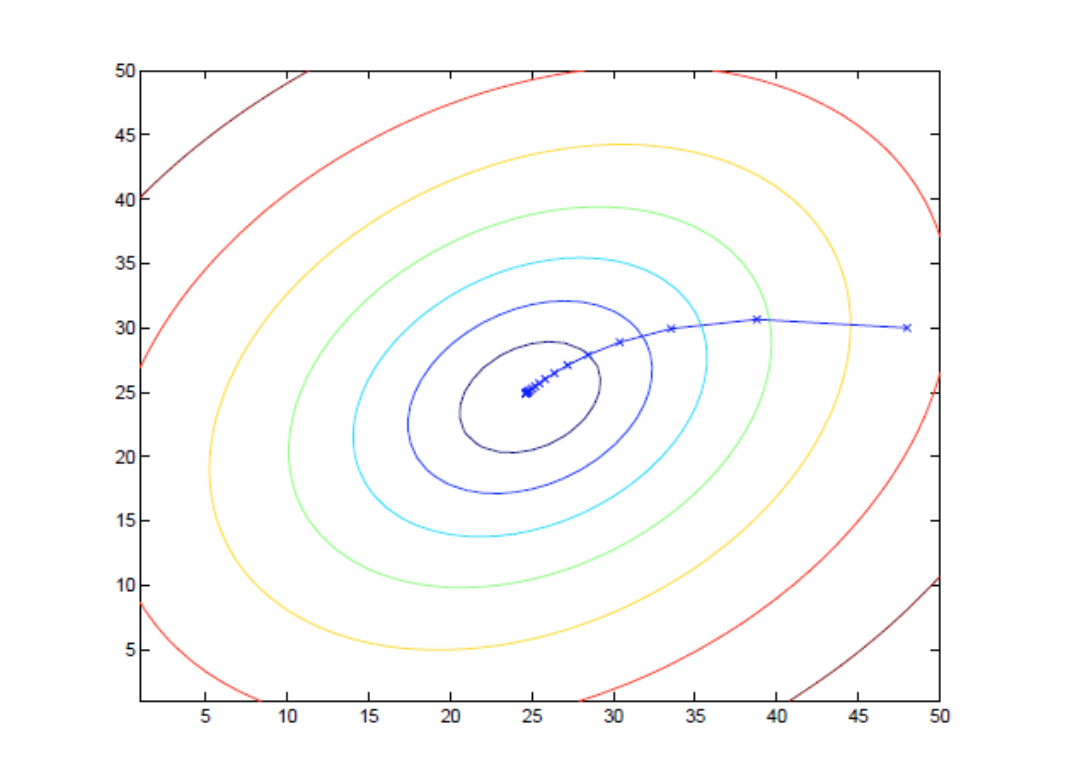

## This is a data science class! I don't wan to do calculus!

Now, this is all well and good, but it assumes that we can compute the gradient $\nabla L$ (i.e., the derivative with respect to each component of $\theta$).
As you hopefully appreciate from your calculus classes and subsequent ML/statistics courses, this is not always so easy!


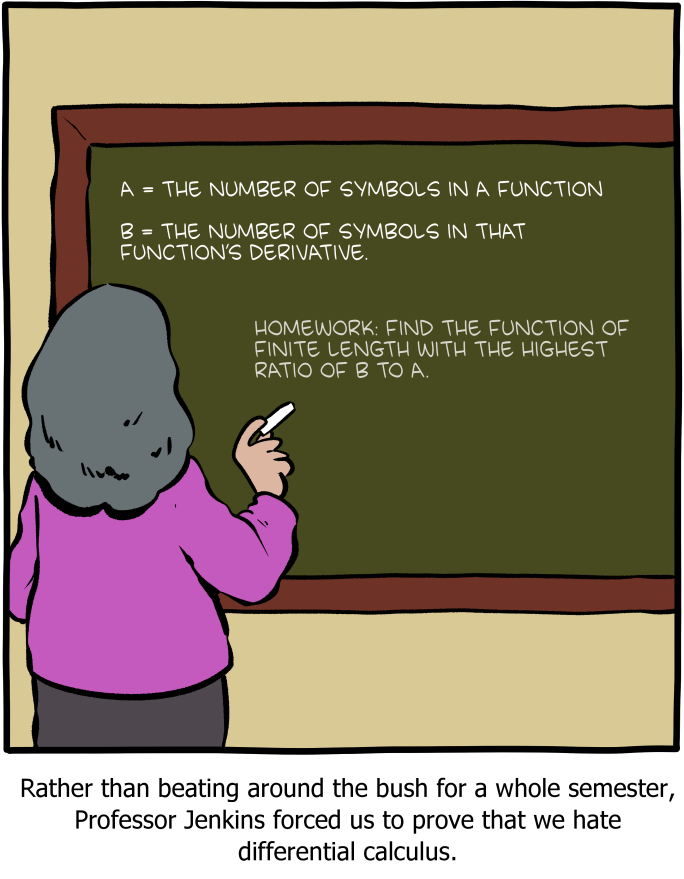

This is where <b>autodifferentiation</b> comes in. It provides a tool to take the derivative of <b>any function</b> (in theory, anyway-- we'll come back to this point).

Really, though, all of autodifferentiation boils down to applying the chain rule:
$$
(f \circ g)'(t) = f'( g(t) ) g'(t).
$$
It's simply that computers are much better at handling the bookkeeping involved in applying this identify for much more complicated function compositions.

The function graph, discussed in lecture (see https://www.tensorflow.org/guide/intro_to_graphs for review), encodes all of the function composition information that is required to apply the chain rule and determine the gradient of any tensor with respect to any other in our program. 

### Let's go to the tape!

The TF `GradientTape` class keeps track of the tensors that we build and how they depend on one another in order to compute whatever gradient we ask.
In essence, the `GradientTape` does the job of looking at the function graph and computing the gradient that we need later. See here for documentation: https://www.tensorflow.org/api_docs/python/tf/GradientTape

Here's a simple example of taking the derivative of $f(x) = x^2$.

In [ ]:
# We need our tensor to have a value-- 3.0 here is arbitrary.
x = tf.Variable(3.0)

with tf.GradientTape() as t: # We are asking the GradientTape to explicitly track y and x, here.
    y = x**2

At this point, TF has memorized that $y=x^2$, and it knows how to compute the gradient of `y` with respect to `x`, which we know to be $dy/ dx = d(x^2)/dx = 2x$.

Let's verify that this is the case.

In [ ]:
dy_dx = t.gradient(y, x) # Actually compute the gradient!

# x has a value, so we can ask what the numerical value of dy_dx is.
dy_dx.numpy()

We set `x` to `3.0` above, so this checks out-- `2*3.0 == 6.0`.

If we change the value of `x`, the value of this gradient changes, as well.

But note that, crucially, we have to re-initialize the GradientTape, as well!

In [ ]:
x.assign(-3.1415)

with tf.GradientTape() as t:
    y = x**2
dy_dx = t.gradient(y, x)

dy_dx.numpy()

<b>Exercise:</b> Pick a (reasonably) complicated function (ideally one for which you know the derivative, though!), implement it in a TensorFlow expression (i.e., `y= [EXPRESSION INVOLVING x]`), and use the `tf.GradientTape` to compute (numerically) the derivative of `y` with respect to `x` at some particular value of `x`. Then, check that this gradient is correct (up to floating point arithmetic)

Here are some suggestions in case you are feeling uninspired: $y = \sin x$; $y = e^x$; $y= x^2 e^x$; $y=-x^3$; $y = x \log x$

In [ ]:
# TODO: code goes here.

## Higher dimensions

Most of the time, we do not care about taking the derivative with respect to a single number.
Instead, we usually have models with at least a few parameters (e.g., regression with multiple predictors).
When it comes time to work with more complicated neural nets, we need to take the derivative with respect to thousands or millions of parameters at once.

This is not a problem for TensorFlow (at least in principle).
Here's an example of taking the derivative with respect to two different multi-dimensional parameters:


In [ ]:
w = tf.Variable(tf.random.normal((3, 2)), name='w')
b = tf.Variable(tf.zeros(2, dtype=tf.float32), name='b')
x = [[1., 2., 3.]]

with tf.GradientTape(persistent=True) as tape:
    y = x @ w + b
    # Okay, this is silly--
    # usually our loss is the difference between our predictions wx+b and the observed responses.
    # This is kind of assuming the true response was 0. Don't worry about it, it's just for demo purposes.
    loss = tf.reduce_mean(y**2)


We can compute the gradient with respect to both w and b by asking for it!
The syntax is just a bit more complicated


In [ ]:
[dloss_dw, dloss_db] = tape.gradient(loss, [w, b])

Now, here's an important point, especially if you haven't seen gradient descent before.
`dloss_dw` and `dloss_db` are both tensors.
What are their shapes?
Better yet, what SHOULD their shapes be?

Well, `dloss_dw` is a gradient, and the gradient with respect to a matrix of values $w \in \mathbb{R}^{m \times n}$ is defined to be another matrix $\nabla L \in \mathbb{R}^{m \times n}$ (i.e., with the same shape as $w$), with $(i,j)$-entry
$$
\left[ \nabla L \right]_{i,j} = \frac{ d L }{ d w_{i,j} }
$$
for $i=1,2,\dots,m$ and $j=1,2,\dots,n$.

<b>Important note:</b> if you recall the Jacobian from your calculus courses, this is NOT the same thing, even though it is also a matrix of derivatives (though it's related!).

Okay, so our `w` above is 3-by-2, so `dloss_dw` should also be 3-by-2...

In [ ]:
print(w.shape)
print(dloss_dw.shape)

In [ ]:
# The same reasoning applies to b, of course.
print(b.shape)
print(dloss_db.shape)

We can also compute the same gradient by passing a dictionary instead of a list of variables.
There's no real difference; just a matter of convenience:

In [ ]:
my_vars = {
    'weight_mx': w,
    'intercept': b
}

grad = tape.gradient(loss, my_vars)
grad['weight_mx']

In Monday's exercises, we had a setup where we had a model (our Poisson regression model) that had a few parameters in it ($\alpha$ and $\beta$), and we had a loss function, which measured how well our predicted responses $\lambda(X_i; \alpha, \beta)$ agreed with the observed responses $Y_i$.

Here's that code for ease of reference:

In [ ]:
class PoissonRegressionModel(tf.Module):
    def __init__(self, name=None, dim=1):
        super().__init__(name=name)
        self.alpha = tf.Variable( [0.0], dtype=tf.float32 )
        self.beta = tf.Variable( dim*[[0.0]], dtype=tf.float32 )
        
    def poislambda(self, x):
        return tf.math.exp( self.alpha + x@self.beta )
    
    def __call__(self, x):
        return self.poislambda(x)
    
def poisloss( y, lam ):
    return -tf.reduce_sum( y*tf.math.log(lam) - lam )

Of course, to fit that model, we also needed data, so let's generate that again.

In [ ]:
def poislambda( x, alpha, beta ):
    return tf.math.exp( x@beta + alpha )
poislambda = tf.function(poislambda)
                         
def generate_pois_reg( n, alpha, beta ):
    rng = np.random.default_rng() # We could also use TF's random submodule; doesn't matter.
    X = np.random.uniform(-2,2,size=(n,beta.shape[0]) )
    X = np.float32(X)
    lam = poislambda( X, alpha, beta)
    Y = np.random.poisson( lam )
    return (X,Y)

alphatrue = tf.constant( [2.7182], dtype=tf.float32 )
betatrue = tf.constant( [[-1.0],[0.5],[0.75],[-0.618]], dtype=tf.float32 )
n = 5000
(X, Y) = generate_pois_reg( n, alphatrue, betatrue )
plt.scatter( poislambda(X, alphatrue, betatrue), Y )

And let's initialize a model.

In [ ]:
prm = PoissonRegressionModel(name='prm', dim=X.shape[1])

(prm.alpha, prm.beta)

Now, we want to modify the model parameters `prm.alpha` and `prm.beta` so as to minimize the loss
`poisloss( Y, prm(X) )`.

We saw how to do this on Monday using gradient descent, but we treated this procedure as a black box.
We are now equipped to revisit that procedure and understand it a bit better.

Here's the code:

In [ ]:
def poistrain(model, x, y, learning_rate):
    with tf.GradientTape() as t: # Set up the GradientTape
        current_loss = poisloss(y, model(x))
    
    # Compute the gradient.
    (dalpha, dbeta) = t.gradient(current_loss, [model.alpha, model.beta])
    # Use the gradient to update the model parameters.
    model.alpha.assign_sub( learning_rate*dalpha ) # alpha_{t+1} = alpha_t - eta * grad L
    model.beta.assign_sub( learning_rate*dbeta )

In [ ]:
# Reinitialize the model so that we can re-run this block multiple times without weird stuff.
prm = PoissonRegressionModel(name='prm', dim=X.shape[1])

# Now do the training loop.
nsteps = 1000 # Number of training steps to take; 1000 is way more than we actually need.
losses = list(range(nsteps))
for i in range(nsteps):
    poistrain(prm, X, Y, learning_rate=1e-6)
    losses[i] = poisloss(Y, prm(X))
    
plt.xlabel('step'); plt.ylabel('loss'); _ = plt.plot( losses )

Now let's compare our estimates to the truth.

In [ ]:
( prm.alpha.numpy(), alphatrue.numpy() )

In [ ]:
(prm.beta.numpy(), betatrue.numpy())

Not bad!

## Putting it all together

Okay, now it's your turn to try and apply what we saw above.
In the process, we'll see another way to build models in TensorFlow: the `keras.layers` module.

Quoting from the documentation:

"A layer is a callable object that takes as input one or more tensors and that outputs one or more tensors. It involves computation, defined in the call() method, and a state (weight variables). State can be created in various places, at the convenience of the subclass implementer:

- in `__init__()`;
- in the optional `build()` method, which is invoked by the first `__call__()` to the layer, and supplies the shape(s) of the input(s), which may not have been known at initialization time;
- in the first invocation of `call()`, with some caveats discussed below.

Users will just instantiate a layer and then treat it as a callable."

The `tf.keras.layers.Layer` class (https://www.tensorflow.org/api_docs/python/tf/keras/layers/Layer) has a few subclasses, all of which follow this basic setup.
Let's consider the `tf.keras.layers.Dense` class (https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense), which implements a single dense layer in a neural net.
We'll talk more about neural nets next week and see how these actually get used.
For now, let's just build a single-layer neural net with a ReLU activiation (more about this next week, but see here: https://en.wikipedia.org/wiki/Rectifier_(neural_networks))

From the documentation:

"Dense implements the operation: `output = activation(dot(input, kernel) + bias)` where `activation` is the element-wise activation function passed as the activation argument, `kernel` is a weights matrix created by the layer, and `bias` is a bias vector created by the layer (only applicable if `use_bias` is True). These are all attributes of `Dense`."

Now, our `(X,Y)` data above was generated according to a Poisson regression model, and we fit a Poisson regression model to it.
Let's try fitting a single-layer dense perceptron model to it.

Here's our model. It needs to take a four-dimensional input (i.e., the same dimension as `X`), and we'll include a bias term (bias term is included by default) to try and account for the $\alpha$ parameter in the true model.

In [ ]:
layer = tf.keras.layers.Dense(X.shape[1], activation='relu' )

layer

In [ ]:
layer.activation

<b>Important point:</b> this weight matrix `layer.kernel` doesn't get created until we apply our model to data!

In [ ]:
layer.kernel

But if we apply `layer` to our data `X`...

In [ ]:
layer(X) # Recall: layers are "callable"-- we can pass input to them!

The output has the same shape as `X`, and the `kernel` attribute has been populated:

In [ ]:
layer.kernel

This is a 4-by-4 matrix. Given an input $x$ (which has dimension 4-- we specified that in initialization), this model is computing $a( W x + b )$, where $a()$ is the activation function, $W \in \mathbb{R}^{4 \times 4}$ is the kernel ("weight matrix"), and $b \in \mathbb{R}^4$ is the bias.

In [ ]:
layer.bias

Don't worry too much about what's going on under the hood, here-- we'll go into more detail next week when we talk about perceptrons and neural nets specifically.

For now, though, observe that we can apply this (very simple) model to an input and get an output.
Specifically, each of our four-dimensional predictor vectors gets transofmed into another four-dimensional vector.

There's still a small issue: we have to turn that into a single number, which will be our predicted value.
Let's just make that another affine function.

In [ ]:
w = tf.Variable( tf.random.normal( (X.shape[1], 1) ) )
b = tf.Variable( tf.random.normal( (1,) ), dtype=tf.float32 )

prediction = layer(X)@w + b #Reminder: "affine" means linear plus an offset (i.e., intercept)

Let's just check that prediction has the shape it ought to...

In [ ]:
prediction

In [ ]:
X.shape

The last part is your job: set up gradient descent to minimize the mean squared error between this prediction and the true observed responses in `Y`.

One important point: we are going to reinitialize our model before trying to compute/record gradients! Failing to do this can sometimes cause gradients to evaluate to `None` if we forget and accidentally do some intermediate calculations (see https://www.tensorflow.org/guide/autodiff for discussion).

<b>Hint:</b> you may find it useful to implement helper functions `sqloss` and `trainstep`, that compute the sum of squares loss and compute a single gradient step, roughly analogously to our loss and train functions from Monday's lecture. You'll find it useful to allow the `trainstep` function to take an argument `learning_rate`, a float that controls the learning rate (i.e., step size).

In [ ]:
# TODO: code goes here.

Now, the fun part: let's watch our model learn! Use your code to perform 1000 gradient steps (you'll need to play around with the learning rate yourself!)

In [ ]:
# Reinitialize everything for when we want to adjust learning rate
layer = tf.keras.layers.Dense(X.shape[1], activation='relu', )
w = tf.Variable( tf.random.normal( (X.shape[1], 1) ) )
b = tf.Variable( tf.random.normal( (1,) ), dtype=tf.float32 )

# TODO: implement a training loop here. Don't forget to include a vector to record losses so you can
# plot them after the loop finishes!

Okay, if your trajectory was anything like mine, it's definitely a lot more chaotic than the nice smooth trajectory of gradient descent in the Poisson regression model, but it certainly looks like <i>something</i> happened...

<b>Exercise:</b> Once you have optimized the model, compare the squared error of this model against the squared error of the Poisson regression model that we trained above. How does this compare with the loss of the Poisson regression model?

In [ ]:
# TODO: code goes here.

You'll probably find that the "neural" model is about an order of magnitude worse, sadly.
This is meant to be, at least in part, a cautionary illustration that "autodiff" and fancy things like "perceptrons" don't solve all of our problems--
We're going to need to be a bit more clever if we want to beat parametric models!
We'll start to talk about that next week.

One really easy way to fix this, though, is to replace the linear function at the "end" of our model with a nonlinear function: exponentiation.
That is, instead of considering
`prediction = layer(X)@w + b`, try using `prediction = tf.math.exp( layer(X) )`.
As a bonus, try that and see if it does better.
It should do better-- it's almost the same as the Poisson regression model!
Do you see why?